# Análisis Exploratorio de Datos (EDA): Rotación de Clientes de Telecomunicaciones (Telco Customer Churn)

Este cuaderno presenta un análisis exploratorio detallado del conjunto de datos `Telco-Customer-Churn.csv`. El objetivo de este análisis es comprender los factores demográficos, contractuales y de consumo asociados a la **rotación de clientes (churn)** de una compañía de telecomunicaciones, y evaluar si el conjunto de datos es adecuado para la enseñanza de las bases del análisis de datos y la estadística multidimensional.

A lo largo del cuaderno, seguiremos una metodología estructurada en tres pasos para cada sección:
1. **Explicación teórica y objetivo**: Qué haremos y por qué lo haremos (Bloque de Markdown).
2. **Implementación de código**: Código en Python que realiza el análisis y genera las visualizaciones correspondientes (Bloque de Código).
3. **Interpretación analítica**: Explicación detallada de los resultados, utilizando estadísticas precisas y relaciones numéricas concretas (Bloque de Markdown).

## 1. Comprensión General y Estructura del Dataset

### ¿Qué se hará?
Cargaremos el conjunto de datos, inspeccionaremos sus dimensiones generales (número de filas y columnas), identificaremos los tipos de datos de cada variable (categórica, numérica, de identificación) y evaluaremos la presencia de valores faltantes (datos nulos).

### ¿Por qué se hace?
Antes de realizar cualquier cálculo o gráfico, es fundamental conocer la "forma" de los datos y los tipos de variables disponibles. Esto determina qué técnicas estadísticas y de visualización son apropiadas. Además, verificar si hay valores nulos ayuda a planificar la estrategia de limpieza y a entender si el dataset está completo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilos para visualizaciones premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Cargar el dataset
df = pd.read_csv('bronze/Telco-Customer-Churn.csv')

# Mostrar las dimensiones del dataset
print("Dimensiones del DataFrame:")
print(f"  Filas (Registros): {df.shape[0]}")
print(f"  Columnas (Variables): {df.shape[1]}")

# Mostrar información sobre los tipos de variables y valores nulos
print("\nInformación estructural y valores nulos:")
df.info()

# Mostrar los primeros 10 registros del dataset para inspección visual
df.head(10)

Dimensiones del DataFrame:
  Filas (Registros): 7043
  Columnas (Variables): 21

Información estructural y valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 no

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Contexto del Dataset
*   **Origen de los Datos**: Es un conjunto de datos ampliamente utilizado en la comunidad de ciencia de datos (originalmente distribuido por IBM Sample Data Sets), que describe a una compañía ficticia de telecomunicaciones que prestó servicios de telefonía fija e internet a **7,043 clientes en California**.
*   **Moneda**: Los importes de `MonthlyCharges` y `TotalCharges` están expresados en **dólares estadounidenses (USD)**, consistentes con cargos mensuales de servicios de telecomunicaciones residenciales (entre $18.25 y $118.75 al mes).
*   **Variable Objetivo (`Churn`)**: Indica si el cliente canceló el servicio en el último mes (`Yes`/`No`). Es la variable central de todo el análisis, ya que el objetivo de negocio es identificar los factores que predicen o explican la deserción de clientes.

### Diccionario de Variables y Traducción al Español

| Variable Original | Traducción al Español | Descripción | Tipo de Variable |
| :--- | :--- | :--- | :--- |
| **customerID** | Identificador de Cliente | Código único alfanumérico que identifica a cada cliente. | Cualitativa Nominal |
| **gender** | Género | Sexo biológico del cliente (Male, Female). | Cualitativa Nominal |
| **SeniorCitizen** | Adulto Mayor | Indica si el cliente es adulto mayor (1 = Sí, 0 = No). | Cualitativa Nominal Binaria (codificada) |
| **Partner** | Tiene Pareja | Indica si el cliente tiene pareja (Yes/No). | Cualitativa Nominal |
| **Dependents** | Tiene Dependientes | Indica si el cliente tiene personas dependientes a su cargo (Yes/No). | Cualitativa Nominal |
| **tenure** | Antigüedad (meses) | Número de meses que el cliente ha permanecido en la compañía. | Cuantitativa Discreta |
| **PhoneService** | Servicio Telefónico | Indica si el cliente tiene servicio de telefonía (Yes/No). | Cualitativa Nominal |
| **MultipleLines** | Líneas Múltiples | Indica si el cliente tiene múltiples líneas telefónicas (Yes/No/No phone service). | Cualitativa Nominal |
| **InternetService** | Servicio de Internet | Tipo de proveedor de internet contratado (DSL, Fiber optic, No). | Cualitativa Nominal |
| **OnlineSecurity** | Seguridad en Línea | Indica si el cliente contrató seguridad en línea (Yes/No/No internet service). | Cualitativa Nominal |
| **OnlineBackup** | Respaldo en Línea | Indica si el cliente contrató respaldo en línea (Yes/No/No internet service). | Cualitativa Nominal |
| **DeviceProtection** | Protección de Dispositivo | Indica si el cliente contrató protección de dispositivo (Yes/No/No internet service). | Cualitativa Nominal |
| **TechSupport** | Soporte Técnico | Indica si el cliente contrató soporte técnico (Yes/No/No internet service). | Cualitativa Nominal |
| **StreamingTV** | TV en Streaming | Indica si el cliente contrató TV por streaming (Yes/No/No internet service). | Cualitativa Nominal |
| **StreamingMovies** | Películas en Streaming | Indica si el cliente contrató streaming de películas (Yes/No/No internet service). | Cualitativa Nominal |
| **Contract** | Tipo de Contrato | Duración del contrato (Month-to-month, One year, Two year). | Cualitativa Ordinal |
| **PaperlessBilling** | Facturación Electrónica | Indica si el cliente usa facturación sin papel (Yes/No). | Cualitativa Nominal |
| **PaymentMethod** | Método de Pago | Forma de pago utilizada (Electronic check, Mailed check, Bank transfer, Credit card). | Cualitativa Nominal |
| **MonthlyCharges** | Cargo Mensual | Monto facturado mensualmente al cliente (USD). | Cuantitativa Continua |
| **TotalCharges** | Cargo Total | Monto total facturado al cliente durante toda su relación con la empresa (USD). | Cuantitativa Continua |
| **Churn** | Rotación / Deserción | **Variable objetivo**: indica si el cliente canceló el servicio en el último mes (Yes/No). | Cualitativa Nominal Binaria |

### Interpretación del Resultado
- **Dimensiones del Dataset**: El conjunto de datos tiene exactamente **7,043 filas y 21 columnas**. Es un tamaño muestral moderado, suficiente para análisis estadísticos descriptivos e inferenciales, aunque considerablemente menor que datasets sintéticos de decenas de miles de registros.
- **Valores Nulos Reportados por Pandas**: `df.info()` reporta **0 valores nulos** en las 21 columnas. Sin embargo, esto es engañoso: la columna `TotalCharges` fue cargada con tipo `object` (texto) en lugar de numérico, lo cual es la primera señal de alerta de que contiene valores no numéricos ocultos (celdas con espacios en blanco) que Pandas no reconoce como `NaN` por defecto. Este hallazgo se investigará y corregirá en la siguiente sección.
- **Clasificación de Variables según su Naturaleza Estadística**:
  1. **Variables Cualitativas (Categóricas)**:
     - **Nominales binarias** (dos categorías sin orden): `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn` (la variable objetivo) y `SeniorCitizen` (codificada numéricamente como 0/1, pero conceptualmente binaria).
     - **Nominales multicategoría**: `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod`.
     - **Ordinal**: `Contract` (Month-to-month < One year < Two year, con una jerarquía temporal implícita).
     - **Identificador**: `customerID` (no es una variable analítica, solo una clave única).
  2. **Variables Cuantitativas (Numéricas)**:
     - **Discreta**: `tenure` (antigüedad en meses, valores enteros de 0 a 72).
     - **Continuas**: `MonthlyCharges` (cargo mensual) y `TotalCharges` (cargo acumulado total, actualmente mal tipada como texto).

## 2. Limpieza y Preparación Inicial de los Datos

### ¿Qué se hará?
Evaluaremos la presencia de registros duplicados globales o identificadores duplicados (`customerID`). Convertiremos `TotalCharges` a tipo numérico, identificando y tratando las celdas no numéricas ocultas. Verificaremos la consistencia lógica entre `tenure`, `MonthlyCharges` y `TotalCharges`, y confirmaremos la codificación de `SeniorCitizen`.

### ¿Por qué se hace?
La preparación inicial garantiza la integridad de los datos antes de cualquier análisis estadístico. Una columna numérica mal tipada como texto (`TotalCharges`) impediría calcular estadísticas descriptivas, correlaciones o ajustar modelos. Verificar la relación lógica entre antigüedad, cargo mensual y cargo total permite validar si el dataset es internamente coherente, y detectar registros de clientes recién ingresados que aún no generan historial de facturación.

In [2]:
# 1. Verificar registros duplicados globales y de identificador
dups = df.duplicated().sum()
id_dups = df['customerID'].duplicated().sum()
print(f"Registros duplicados globales: {dups}")
print(f"customerID duplicados: {id_dups}")
print(f"customerID únicos: {df['customerID'].nunique()} de {len(df)} registros")

# 2. Detectar celdas no numéricas ocultas en TotalCharges
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(f"\nCeldas en blanco en TotalCharges: {blank_mask.sum()}")
print("Antigüedad (tenure) de los clientes con TotalCharges en blanco:")
print(df.loc[blank_mask, 'tenure'].value_counts())

# 3. Convertir TotalCharges a numérico y corregir los casos de tenure = 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print(f"\nNuevo dtype de TotalCharges: {df['TotalCharges'].dtype}")

# 4. Verificar consistencia lógica: TotalCharges vs. tenure * MonthlyCharges
approx_total = df['tenure'] * df['MonthlyCharges']
diff = (approx_total - df['TotalCharges']).abs()
corr_check = df['TotalCharges'].corr(approx_total)
print(f"\nDiferencia media absoluta (tenure * MonthlyCharges vs TotalCharges): ${diff.mean():.2f}")
print(f"Diferencia mediana absoluta: ${diff.median():.2f}")
print(f"Correlación entre TotalCharges y (tenure * MonthlyCharges): {corr_check:.4f}")

# 5. Confirmar codificación de SeniorCitizen
print(f"\nValores únicos de SeniorCitizen: {sorted(df['SeniorCitizen'].unique())}")

# 6. Codificar la variable objetivo como numérica auxiliar para correlaciones
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

Registros duplicados globales: 0
customerID duplicados: 0
customerID únicos: 7043 de 7043 registros

Celdas en blanco en TotalCharges: 11
Antigüedad (tenure) de los clientes con TotalCharges en blanco:
tenure
0    11
Name: count, dtype: int64

Nuevo dtype de TotalCharges: float64

Diferencia media absoluta (tenure * MonthlyCharges vs TotalCharges): $45.02
Diferencia mediana absoluta: $28.60
Correlación entre TotalCharges y (tenure * MonthlyCharges): 0.9996

Valores únicos de SeniorCitizen: [np.int64(0), np.int64(1)]


### Interpretación del Resultado
- **Registros Duplicados**: Se confirmaron **0 registros duplicados globales** y **0 `customerID` duplicados**; los 7,043 identificadores son únicos, por lo que cada fila representa un cliente distinto.
- **`TotalCharges` Mal Tipada**: Se encontraron **11 celdas en blanco** (espacios en lugar de un número) en `TotalCharges`. Las 11 corresponden exactamente a clientes con **`tenure = 0`** (clientes que se acaban de suscribir y aún no han recibido ni pagado una factura), lo cual es lógicamente coherente: al no tener historial de facturación, el cargo total acumulado es efectivamente cero. Tras convertir la columna a tipo numérico (`float64`) e imputar estos 11 casos con **0.0**, el dataset queda completamente limpio y apto para análisis cuantitativo.
- **Consistencia entre `tenure`, `MonthlyCharges` y `TotalCharges`**: La aproximación `tenure × MonthlyCharges` tiene una correlación de **0.9996** con `TotalCharges` real, con una diferencia media absoluta de apenas **$45.02** (mediana de $28.60) sobre montos que llegan hasta $8,684.80. Esta pequeña discrepancia es completamente esperable en un dataset real: los clientes no siempre pagaron exactamente el mismo cargo mensual actual durante toda su permanencia (pudieron cambiar de plan, recibir promociones o ajustes de tarifa), a diferencia del dataset sintético de tarjetas de crédito donde las fórmulas eran exactas. Esta ligera imperfección es, de hecho, un indicio de que se trata de datos con mayor realismo.
- **Codificación de `SeniorCitizen`**: Confirmado que solo toma los valores **{0, 1}**, es decir, ya viene pre-codificada como variable binaria numérica en lugar de texto (`Yes`/`No`) como el resto de las variables categóricas binarias del dataset.

## 3. Análisis Univariado

### ¿Qué se hará?
En primer lugar, analizaremos la distribución de la **variable objetivo (`Churn`)**, pieza central de este análisis. Luego examinaremos la distribución de las variables categóricas más relevantes (`gender`, `Contract`, `InternetService`, `PaymentMethod`) y de las variables numéricas clave (`tenure`, `MonthlyCharges`, `TotalCharges`) mediante frecuencias, medidas de tendencia central y dispersión, e histogramas con curvas de densidad (KDE).

### ¿Por qué se hace?
Antes de buscar relaciones entre variables, es indispensable entender el comportamiento individual de cada una. Conocer el balance de clases de `Churn` es crítico: un fuerte desbalance afecta la interpretación de cualquier modelo predictivo posterior. De igual forma, entender la forma de las distribuciones numéricas (sesgo, concentración) ayuda a decidir si se requieren transformaciones o agrupaciones (binning) más adelante.

/tmp/ipykernel_17650/2406459622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=axes[0], palette='pastel', order=['No', 'Yes'])


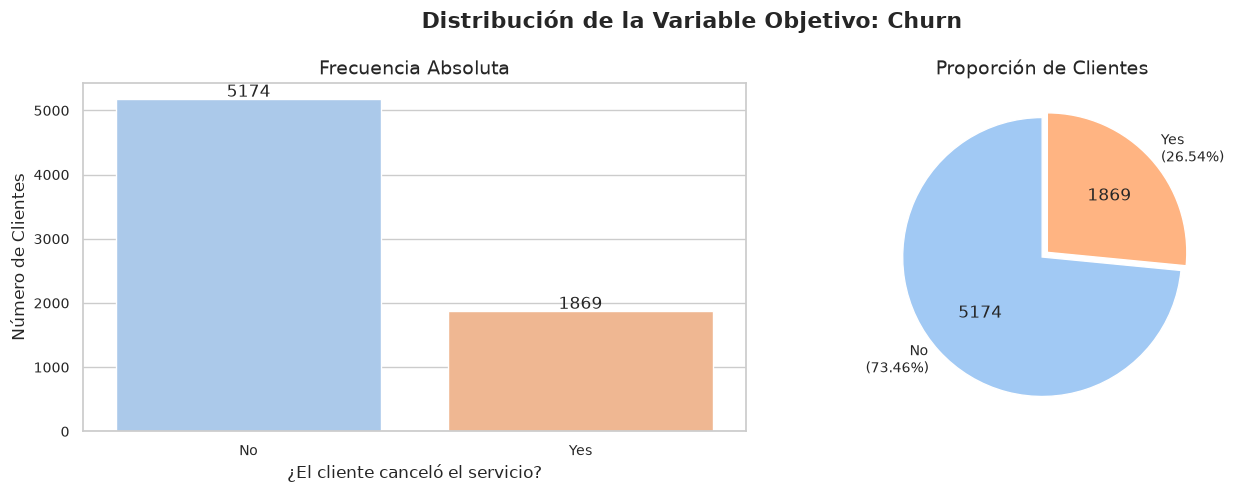

--- Frecuencias exactas de Churn ---
  No: 5174 clientes (73.46%)
  Yes: 1869 clientes (26.54%)


In [3]:
# Distribución de la variable objetivo: Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de la Variable Objetivo: Churn', fontsize=16, fontweight='bold')

churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

sns.countplot(x='Churn', data=df, ax=axes[0], palette='pastel', order=['No', 'Yes'])
axes[0].set_title('Frecuencia Absoluta')
axes[0].set_xlabel('¿El cliente canceló el servicio?')
axes[0].set_ylabel('Número de Clientes')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

axes[1].pie(churn_counts, labels=[f'{idx}\n({churn_pcts[idx]:.2f}%)' for idx in churn_counts.index],
            colors=sns.color_palette('pastel')[0:2], autopct=lambda p: f'{round(p * sum(churn_counts) / 100)}',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporción de Clientes')

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/distribucion_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Frecuencias exactas de Churn ---")
for idx in churn_counts.index:
    print(f"  {idx}: {churn_counts[idx]} clientes ({churn_pcts[idx]:.2f}%)")

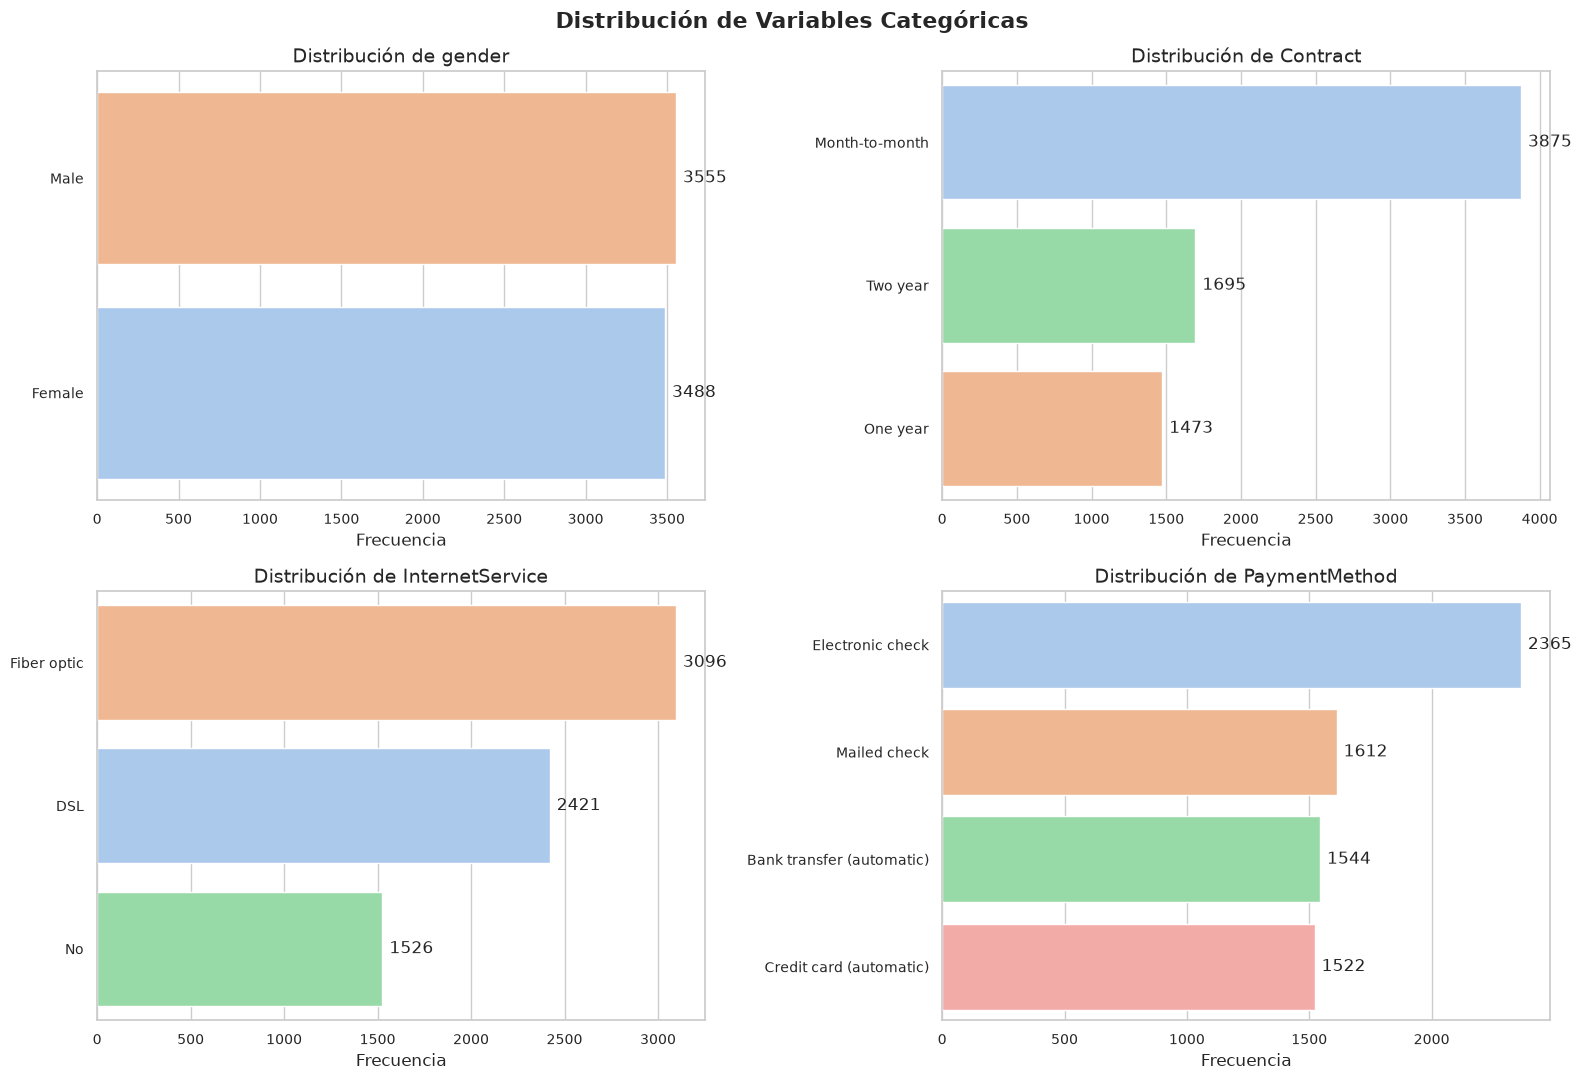

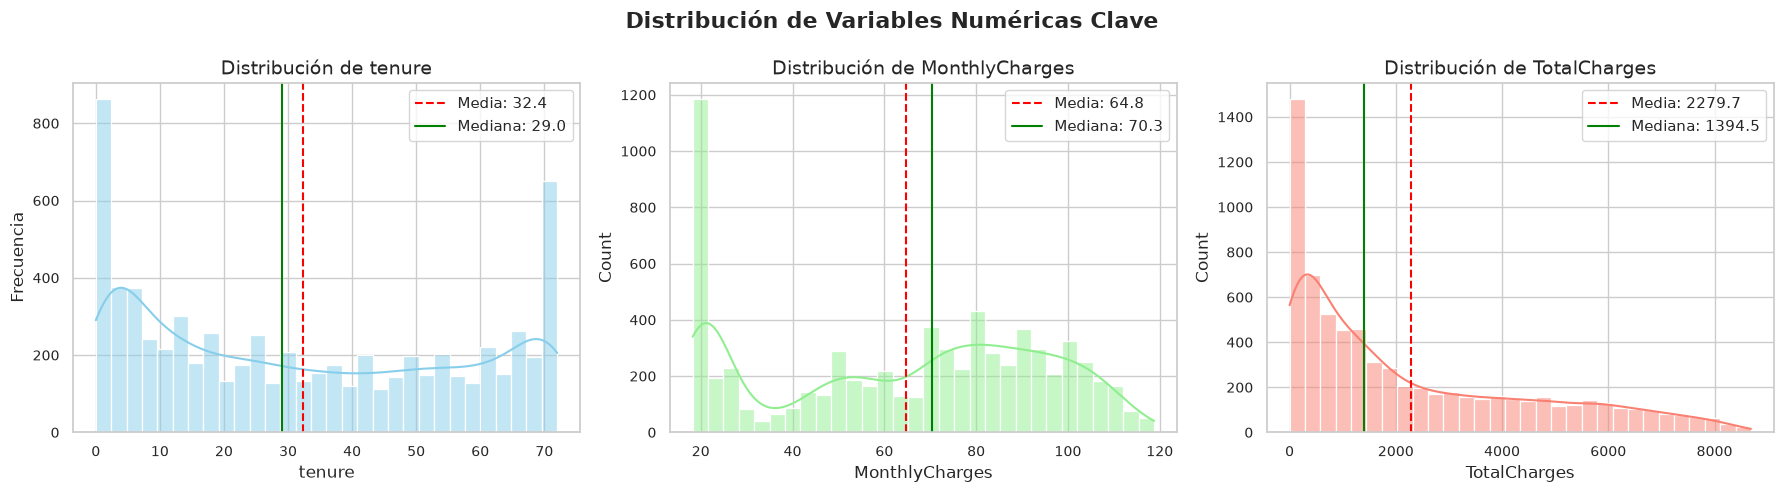

--- Frecuencias Exactas Categóricas ---

Frecuencias para gender:
  Male: 3555 registros (50.48%)
  Female: 3488 registros (49.52%)

Frecuencias para Contract:
  Month-to-month: 3875 registros (55.02%)
  Two year: 1695 registros (24.07%)
  One year: 1473 registros (20.91%)

Frecuencias para InternetService:
  Fiber optic: 3096 registros (43.96%)
  DSL: 2421 registros (34.37%)
  No: 1526 registros (21.67%)

Frecuencias para PaymentMethod:
  Electronic check: 2365 registros (33.58%)
  Mailed check: 1612 registros (22.89%)
  Bank transfer (automatic): 1544 registros (21.92%)
  Credit card (automatic): 1522 registros (21.61%)

--- Estadísticas Descriptivas Numéricas ---
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      5

In [4]:
# Distribución de variables categóricas relevantes
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')

cat_plot_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod']
for ax, col in zip(axes.flatten(), cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=ax, order=order, palette='pastel', hue=col, legend=False)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.0f}', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/distribucion_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribución de variables numéricas clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas Clave', fontsize=16, fontweight='bold')

num_plot_cols = [('tenure', 'skyblue'), ('MonthlyCharges', 'lightgreen'), ('TotalCharges', 'salmon')]
for ax, (col, color) in zip(axes, num_plot_cols):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.legend()
axes[0].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/distribucion_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir las frecuencias exactas
print("--- Frecuencias Exactas Categóricas ---")
for col in cat_plot_cols:
    print(f"\nFrecuencias para {col}:")
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    for idx in counts.index:
        print(f"  {idx}: {counts[idx]} registros ({pcts[idx]:.2f}%)")

print("\n--- Estadísticas Descriptivas Numéricas ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2).to_string())

### Interpretación del Resultado

#### Variable Objetivo: Churn
El dataset presenta un **desbalance de clases moderado**: **5,174 clientes (73.46%) no cancelaron el servicio (`No`)**, mientras que **1,869 clientes (26.54%) sí lo cancelaron (`Yes`)**. La proporción es de aproximadamente **2.77 clientes retenidos por cada cliente perdido**. Este desbalance es realista para un problema de rotación de clientes y debe tenerse en cuenta al interpretar cualquier modelo predictivo posterior (una estrategia ingenua que siempre prediga "No" ya acertaría el 73.46% de las veces).

#### Variables Categóricas
- **Género (`gender`)**: Está prácticamente balanceado, con **3,555 hombres (50.48%)** y **3,488 mujeres (49.52%)**. Esta variable no introduce sesgos de muestreo relevantes.
- **Tipo de Contrato (`Contract`)**: La mayoría de los clientes, **3,875 (55.02%)**, tiene un contrato **Month-to-month** (mes a mes, sin permanencia). Le siguen **Two year con 1,695 clientes (24.07%)** y **One year con 1,473 clientes (20.91%)**. Esta alta proporción de contratos flexibles de corto plazo es clave, ya que anticipa mayor probabilidad de cancelación (se explora en la Sección 5).
- **Servicio de Internet (`InternetService`)**: **Fiber optic** es el más común con **3,096 clientes (43.96%)**, seguido de **DSL con 2,421 (34.37%)** y clientes **sin servicio de internet (`No`) con 1,526 (21.67%)**.
- **Método de Pago (`PaymentMethod`)**: **Electronic check** predomina con **2,365 clientes (33.58%)**, mientras que los otros tres métodos (Mailed check, Bank transfer automático, Credit card automático) se reparten de forma relativamente equitativa entre el 21.6% y el 22.9% cada uno.

#### Variables Numéricas
- **Antigüedad (`tenure`)**: Tiene una media de **32.37 meses** y una mediana de **29.0 meses**, con un rango de **0 a 72 meses** (6 años, el tope observado en el dataset). Su distribución es notablemente **bimodal**: existe una alta concentración de clientes muy nuevos (cerca de 0 meses) y otra concentración considerable de clientes con la antigüedad máxima (~72 meses), con una zona intermedia menos densa. Esto sugiere dos grupos de comportamiento contrapuestos: clientes que abandonan tempranamente y clientes altamente leales de largo plazo.
- **Cargo Mensual (`MonthlyCharges`)**: Media de **$64.76** y mediana de **$70.35**, en un rango de **$18.25 a $118.75**. Su distribución también es **bimodal**: un primer pico muy pronunciado cerca de $20 (clientes con solo servicio telefónico básico, sin internet) y un segundo pico más amplio entre $75 y $105 (clientes con paquetes de internet, especialmente fibra óptica). No existe una transición suave entre ambos grupos, lo que confirma que el catálogo de planes de la compañía separa claramente a los clientes de bajo consumo de los de paquetes combinados.
- **Cargo Total (`TotalCharges`)**: Media de **$2,279.73** y mediana de **$1,394.55**, en un rango de **$0 a $8,684.80**. Al ser una variable acumulada a lo largo del tiempo de permanencia, presenta un fuerte sesgo a la derecha (cola larga), coherente con la naturaleza bimodal de `tenure`: muchos clientes recientes acumulan poco cargo total, mientras que unos pocos clientes de larga data acumulan montos elevados.

## 4. Detección de Valores Atípicos (Outliers)

### ¿Qué se hará?
Utilizaremos el método del Rango Intercuartílico (IQR) para identificar formalmente valores atípicos en las tres variables numéricas continuas/discretas del dataset: `tenure`, `MonthlyCharges` y `TotalCharges`. Visualizaremos estas distribuciones mediante diagramas de caja (boxplots) y calcularemos el número exacto de valores que se ubican por debajo del límite inferior ($Q_1 - 1.5 \times IQR$) o por encima del límite superior ($Q_3 + 1.5 \times IQR$).

### ¿Por qué se hace?
Los valores atípicos pueden distorsionar estadísticas descriptivas y modelos predictivos. Sin embargo, en variables de negocio con límites naturales (como la antigüedad de un cliente o un cargo mensual dentro de un catálogo de planes fijo), es igual de valioso confirmar la **ausencia** de outliers, ya que esto certifica que las variables están acotadas de forma realista y no requieren tratamiento adicional antes de un análisis multivariado.

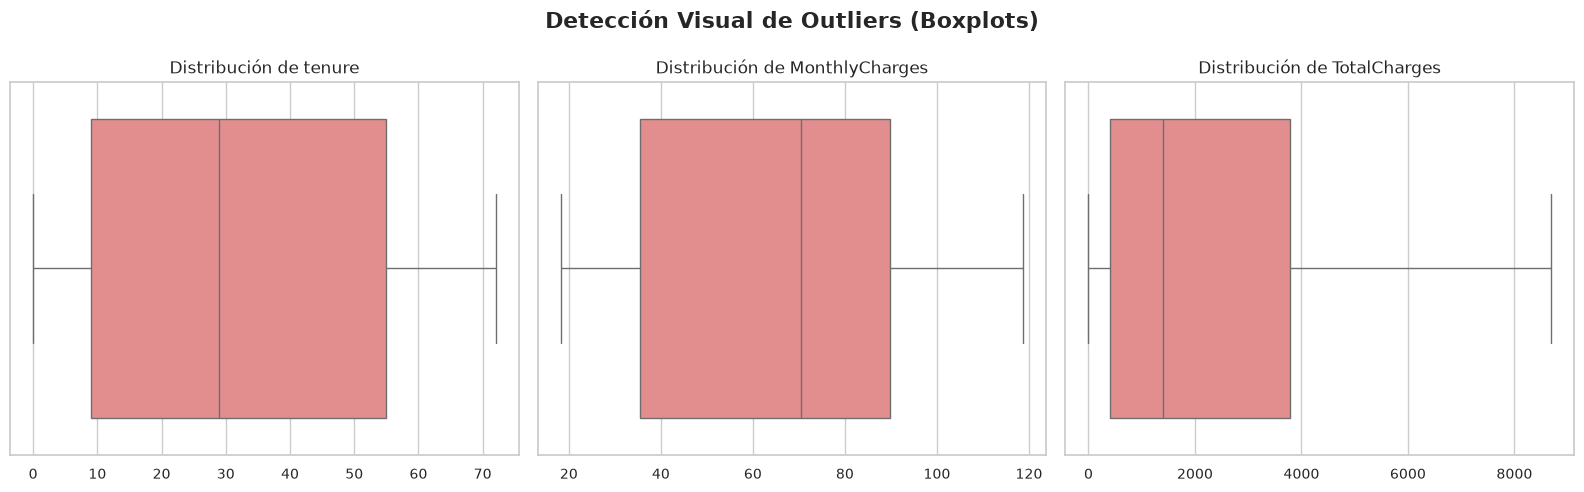

--- Reporte Detallado de Outliers (Método IQR) ---

Variable: tenure
  Q1: 9.00 | Q3: 55.00 | IQR: 46.00
  Límites de aceptación: [-60.00, 124.00]
  Rango real de la variable: [0.00, 72.00]
  Outliers por debajo: 0 (0.00%)
  Outliers por encima: 0 (0.00%)

Variable: MonthlyCharges
  Q1: 35.50 | Q3: 89.85 | IQR: 54.35
  Límites de aceptación: [-46.02, 171.38]
  Rango real de la variable: [18.25, 118.75]
  Outliers por debajo: 0 (0.00%)
  Outliers por encima: 0 (0.00%)

Variable: TotalCharges
  Q1: 398.55 | Q3: 3786.60 | IQR: 3388.05
  Límites de aceptación: [-4683.52, 8868.67]
  Rango real de la variable: [0.00, 8684.80]
  Outliers por debajo: 0 (0.00%)
  Outliers por encima: 0 (0.00%)


In [5]:
outlier_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Detección Visual de Outliers (Boxplots)', fontsize=16, fontweight='bold')

outliers_summary = {}
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral', flierprops=dict(markerfacecolor='red', marker='o', markersize=4))
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_low = df[df[col] < lower_bound]
    outliers_high = df[df[col] > upper_bound]
    total_outliers = len(outliers_low) + len(outliers_high)

    outliers_summary[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower_Bound': lower_bound, 'Upper_Bound': upper_bound,
        'Low_Count': len(outliers_low), 'High_Count': len(outliers_high),
        'Total_Count': total_outliers, 'Percentage': total_outliers / len(df) * 100
    }

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/deteccion_outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Reporte Detallado de Outliers (Método IQR) ---")
for col, s in outliers_summary.items():
    print(f"\nVariable: {col}")
    print(f"  Q1: {s['Q1']:.2f} | Q3: {s['Q3']:.2f} | IQR: {s['IQR']:.2f}")
    print(f"  Límites de aceptación: [{s['Lower_Bound']:.2f}, {s['Upper_Bound']:.2f}]")
    print(f"  Rango real de la variable: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"  Outliers por debajo: {s['Low_Count']} ({s['Low_Count']/len(df)*100:.2f}%)")
    print(f"  Outliers por encima: {s['High_Count']} ({s['High_Count']/len(df)*100:.2f}%)")

### Interpretación del Resultado
El método IQR **no detectó ningún valor atípico (0 outliers, 0.00%)** en ninguna de las tres variables numéricas analizadas:

| Variable | Q1 | Q3 | IQR | Límites de Aceptación | Rango Real | Outliers |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **tenure** | 9.0 | 55.0 | 46.0 | [-60.0, 124.0] | [0, 72] | 0 (0.00%) |
| **MonthlyCharges** | 35.50 | 89.85 | 54.35 | [-46.02, 171.38] | [18.25, 118.75] | 0 (0.00%) |
| **TotalCharges** | 398.55 | 3,786.60 | 3,388.05 | [-4,683.52, 8,868.67] | [0.00, 8,684.80] | 0 (0.00%) |

Esto ocurre porque los límites de aceptación calculados con el factor 1.5×IQR son mucho más amplios que el rango real observado de cada variable: por ejemplo, el límite inferior de `tenure` es -60 meses (imposible en la práctica) y el superior es 124 meses, muy por encima del máximo real de 72. Lo mismo sucede con `TotalCharges`, cuyo límite superior (\$8,868.67) apenas supera el valor máximo observado (\$8,684.80).

**Contraste relevante**: a diferencia del dataset sintético de tarjetas de crédito (donde 8-9% de los registros en variables financieras eran outliers por el fuerte sesgo hacia clientes de alto patrimonio), este dataset de telecomunicaciones **no requiere ningún tratamiento de valores atípicos**. Esto es coherente con la naturaleza del negocio: los cargos mensuales están acotados por un catálogo finito de planes de servicio, y la antigüedad está naturalmente limitada por el tiempo de vida del programa de recolección de datos (72 meses = 6 años). El sesgo derecho observado en `TotalCharges` en la sección anterior es real y considerable, pero no lo suficientemente extremo como para generar valores atípicos bajo el criterio IQR clásico.

## 5. Análisis Bivariado y Multivariado

### ¿Qué se hará?
Cruzaremos la variable objetivo `Churn` con las principales variables categóricas de negocio (`Contract`, `InternetService`, `PaymentMethod`, `SeniorCitizen`) para calcular tasas de rotación específicas por segmento. Compararemos las distribuciones de `tenure` y `MonthlyCharges` entre clientes que cancelaron y los que no mediante boxplots. Finalmente, construiremos un **Mapa de Calor de Correlaciones** de Pearson entre las variables numéricas y la variable objetivo codificada.

### ¿Por qué se hace?
El análisis bivariado es el núcleo de un problema de rotación de clientes: nos permite pasar de "¿cuántos clientes cancelan?" a "¿qué tipo de cliente tiende a cancelar y por qué?". Comparar la tasa de churn entre segmentos (por tipo de contrato, servicio o forma de pago) revela directamente qué políticas comerciales están asociadas a mayor o menor retención, información de gran valor para el diseño de estrategias de fidelización.

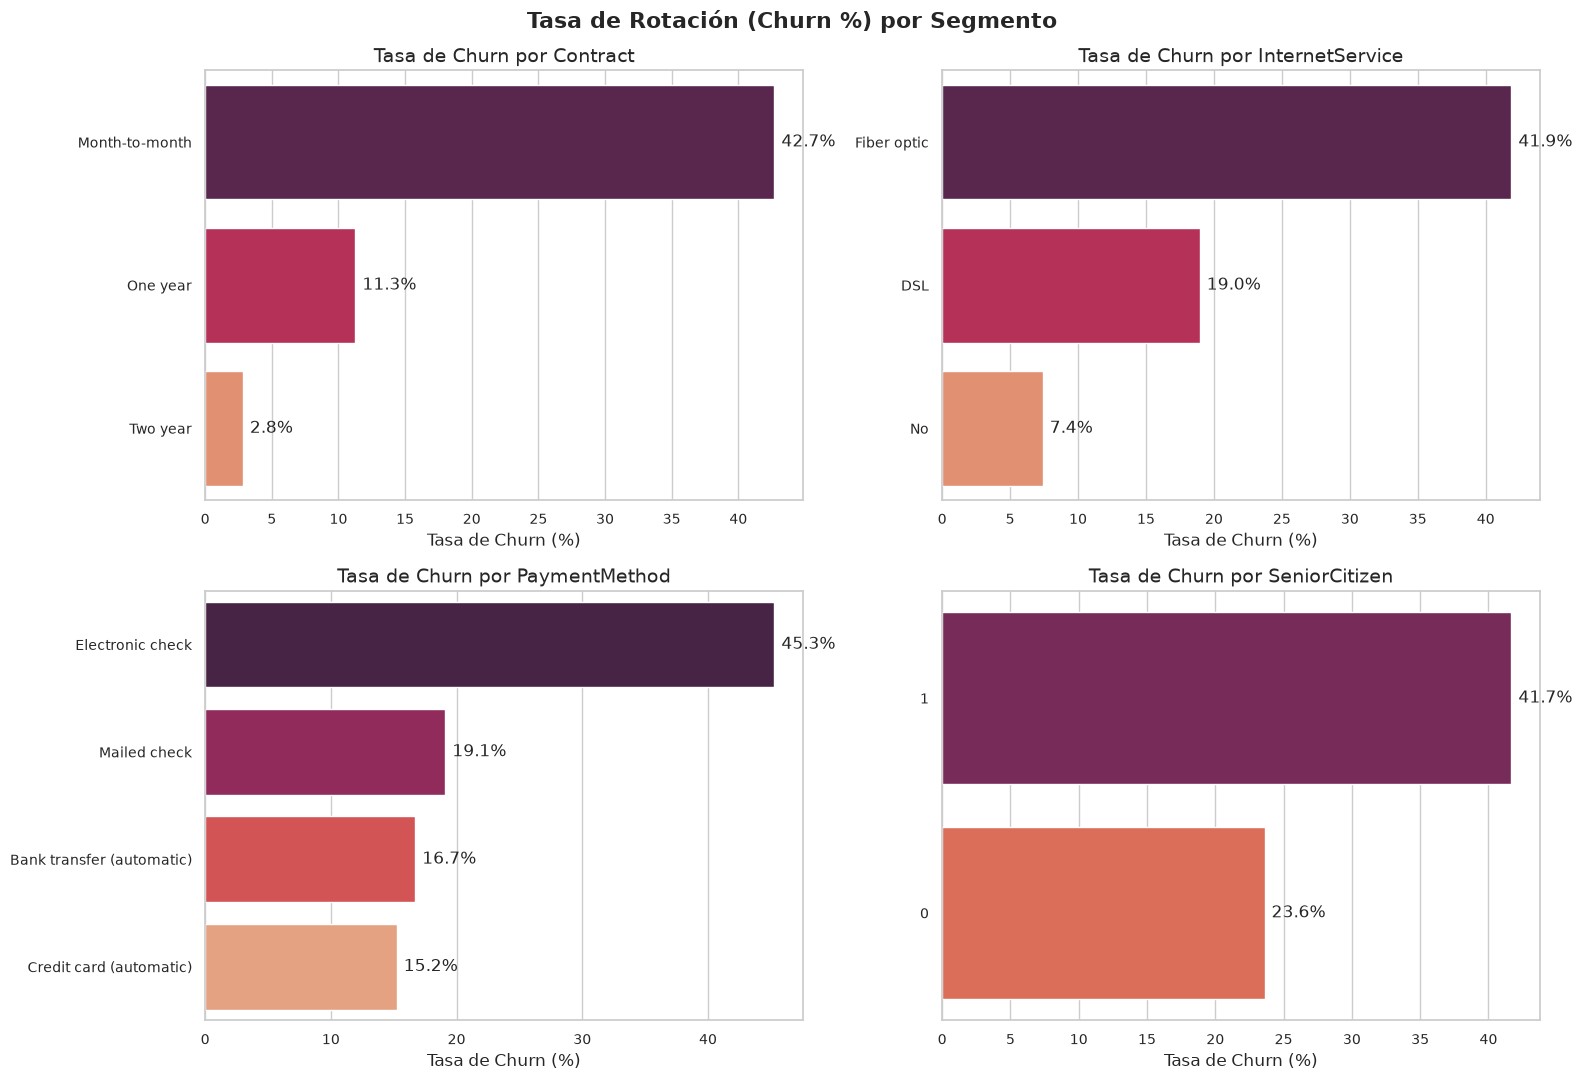

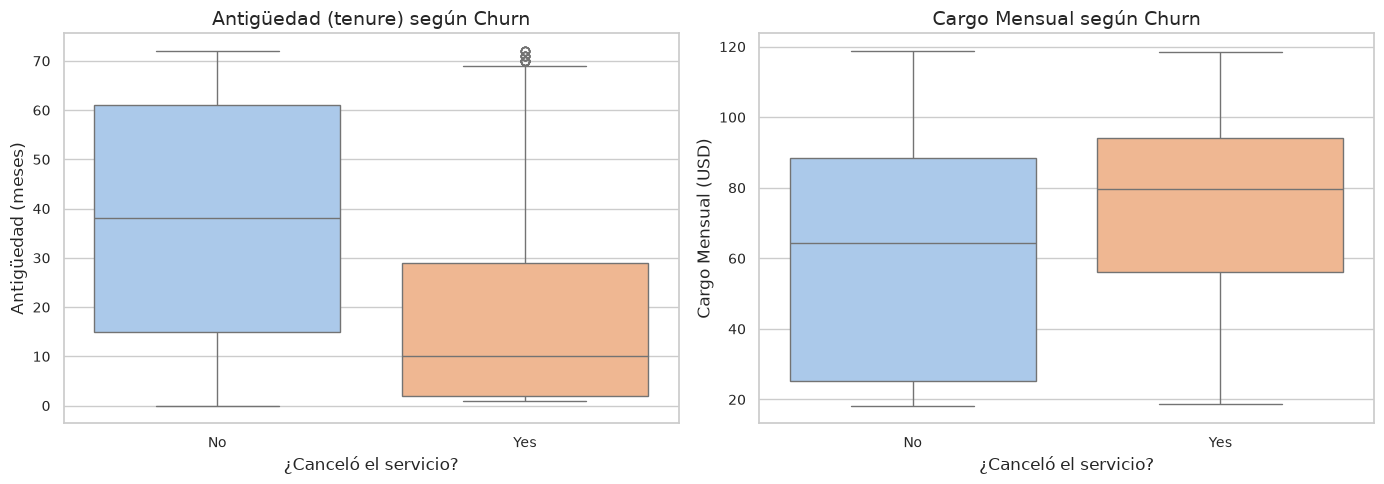

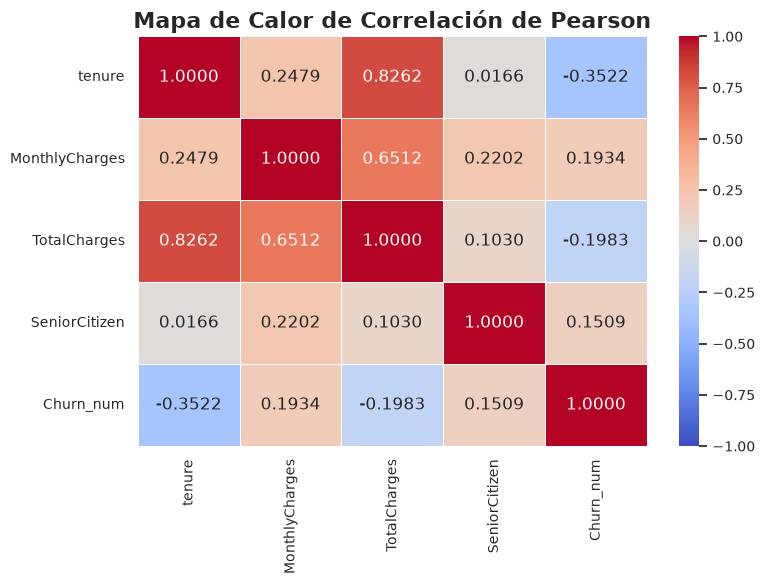

--- Tasa de Churn (%) por Segmento ---

Contract:
  Month-to-month: 42.71%
  One year: 11.27%
  Two year: 2.83%

InternetService:
  Fiber optic: 41.89%
  DSL: 18.96%
  No: 7.40%

PaymentMethod:
  Electronic check: 45.29%
  Mailed check: 19.11%
  Bank transfer (automatic): 16.71%
  Credit card (automatic): 15.24%

SeniorCitizen:
  1: 41.68%
  0: 23.61%

--- Medias de tenure y MonthlyCharges por Churn ---
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [6]:
# 1. Tasa de Churn por variables categóricas clave
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Tasa de Rotación (Churn %) por Segmento', fontsize=16, fontweight='bold')

segment_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']
for ax, col in zip(axes.flatten(), segment_cols):
    rate = (pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'] * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax, palette='rocket', hue=rate.index.astype(str), legend=False)
    ax.set_title(f'Tasa de Churn por {col}')
    ax.set_xlabel('Tasa de Churn (%)')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/tasa_churn_por_segmento.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Comparación de tenure y MonthlyCharges entre clientes que cancelan y no
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], hue='Churn', palette='pastel', order=['No', 'Yes'], legend=False)
axes[0].set_title('Antigüedad (tenure) según Churn')
axes[0].set_xlabel('¿Canceló el servicio?')
axes[0].set_ylabel('Antigüedad (meses)')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], hue='Churn', palette='pastel', order=['No', 'Yes'], legend=False)
axes[1].set_title('Cargo Mensual según Churn')
axes[1].set_xlabel('¿Canceló el servicio?')
axes[1].set_ylabel('Cargo Mensual (USD)')

plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/tenure_monthly_por_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Mapa de calor de correlaciones
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación de Pearson', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/mapa_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir tasas de churn exactas
print("--- Tasa de Churn (%) por Segmento ---")
for col in segment_cols:
    rate = (pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'] * 100).sort_values(ascending=False)
    print(f"\n{col}:")
    for idx, val in rate.items():
        print(f"  {idx}: {val:.2f}%")

print("\n--- Medias de tenure y MonthlyCharges por Churn ---")
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2).to_string())

### Interpretación del Resultado

#### 1. Tasa de Rotación por Tipo de Contrato (el factor más determinante)
La tasa de churn varía de forma dramática según el tipo de contrato:
- **Month-to-month**: **42.71%** de tasa de cancelación.
- **One year**: **11.27%**.
- **Two year**: apenas **2.83%**.
Un cliente con contrato mes a mes tiene una probabilidad de cancelar **más de 15 veces mayor** que uno con contrato a dos años. Esta es, con diferencia, la variable individual más asociada al churn en todo el dataset: la falta de un compromiso de permanencia elimina cualquier fricción de salida.

#### 2. Tasa de Rotación por Servicio de Internet y Método de Pago
- **InternetService**: los clientes con **Fiber optic** cancelan en un **41.89%** de los casos, frente a **18.96%** en DSL y solo **7.40%** entre quienes no tienen internet. Esto es contraintuitivo a primera vista (fibra óptica suele ser el servicio "premium"), pero sugiere que estos clientes pagan tarifas más altas y/o enfrentan mayor competencia de otros proveedores de fibra, aumentando su sensibilidad al precio o al servicio.
- **PaymentMethod**: **Electronic check** presenta la tasa de churn más alta con **45.29%**, muy por encima de Mailed check (19.11%), Bank transfer automático (16.71%) y Credit card automático (15.24%). Los métodos de pago **automáticos** (que no requieren acción mensual del cliente) se asocian claramente a mayor retención.
- **SeniorCitizen**: los adultos mayores cancelan con mayor frecuencia (**41.68%**) que el resto de los clientes (**23.61%**).

#### 3. Antigüedad y Cargo Mensual según Churn
- La **antigüedad promedio** de los clientes que **no** cancelan es de **37.57 meses**, más del doble que la de quienes **sí** cancelan (**17.98 meses**). Los boxplots confirman que los clientes que abandonan se concentran fuertemente en los primeros meses de servicio.
- El **cargo mensual promedio** es más alto entre quienes cancelan (**\$74.44**) que entre quienes permanecen (**\$61.27**), sugiriendo que los planes más costosos están asociados a mayor insatisfacción o sensibilidad al precio.
- Paradójicamente, el **cargo total acumulado** es menor entre quienes cancelan (**\$1,531.80** vs **\$2,549.91**), lo cual es una consecuencia directa de su menor antigüedad y no de un menor gasto mensual.

#### 4. Correlaciones de Pearson
- `tenure` tiene la correlación más fuerte con `Churn_num`: **r = -0.3522** (a mayor antigüedad, menor probabilidad de cancelar).
- `MonthlyCharges` correlaciona positivamente con `Churn_num`: **r = 0.1934** (cargos más altos, mayor tendencia a cancelar).
- `TotalCharges` correlaciona negativamente (**r = -0.1983**), aunque esto es en gran parte un efecto indirecto de su fuerte correlación con `tenure` (**r = 0.8262**), más que una relación causal propia.
- `SeniorCitizen` tiene una correlación positiva débil pero no despreciable con `Churn_num` (**r = 0.1509**), consistente con la mayor tasa de cancelación observada en este grupo.

## 6. Ingeniería de Características, Pruebas Estadísticas y Modelado Explicativo

### ¿Qué se hará?
1. Crearemos la variable `tenure_group`, agrupando la antigüedad en 5 rangos, para visualizar la tasa de churn de forma más granular a lo largo del ciclo de vida del cliente.
2. Aplicaremos la **prueba de independencia Chi-cuadrado (χ²)** entre `Churn` y las principales variables categóricas (`Contract`, `InternetService`, `PaymentMethod`, `SeniorCitizen`, `Partner`, `Dependents`, `PaperlessBilling`) para confirmar formalmente si las asociaciones observadas en la Sección 5 son estadísticamente significativas.
3. Ajustaremos un modelo de **regresión logística** (estandarizando las variables numéricas) para cuantificar el peso relativo de cada factor sobre la probabilidad de cancelación y evaluar su capacidad predictiva global.
4. Formularemos las conclusiones finales sobre la calidad y el valor pedagógico del dataset.

### ¿Por qué se hace?
Observar que dos variables están asociadas visualmente no basta: la prueba Chi-cuadrado permite confirmar con rigor estadístico si esa asociación es real o producto del azar. Por su parte, el modelo de regresión logística —el modelo estándar para problemas de clasificación binaria como el churn— permite sintetizar el efecto conjunto de múltiples variables y comparar su importancia relativa en una sola ecuación, cerrando el análisis con una herramienta explicativa y predictiva.

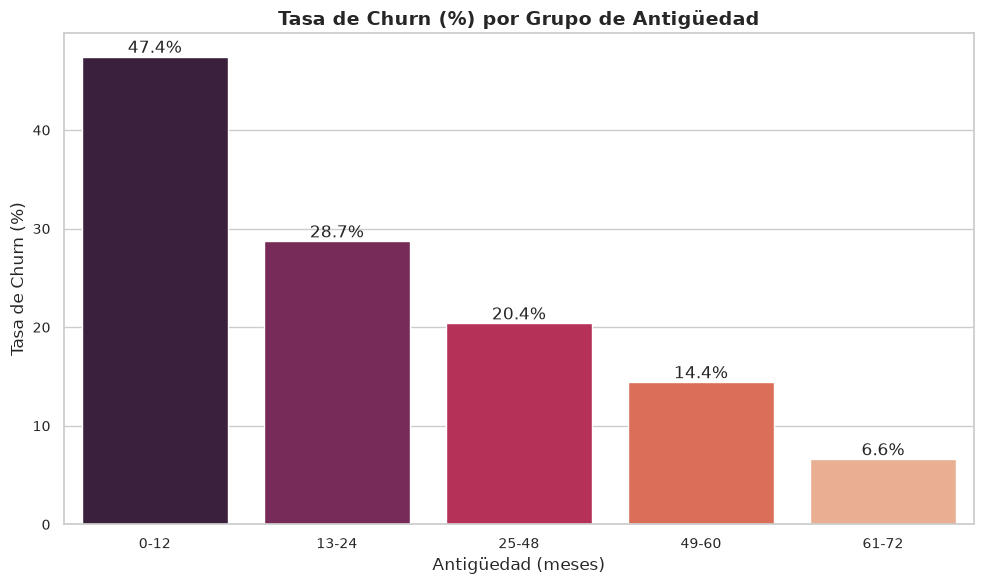

--- Tasa de Churn por Grupo de Antigüedad ---
              count    mean
tenure_group               
0-12           2186  0.4744
13-24          1024  0.2871
25-48          1594  0.2039
49-60           832  0.1442
61-72          1407  0.0661

--- Pruebas Chi-cuadrado de Independencia con Churn ---
  Contract          : chi2 =  1184.60 | p-valor = 5.8630e-258 | gl = 2 | Significativo (p<0.001): Sí
  InternetService   : chi2 =   732.31 | p-valor = 9.5718e-160 | gl = 2 | Significativo (p<0.001): Sí
  PaymentMethod     : chi2 =   648.14 | p-valor = 3.6824e-140 | gl = 3 | Significativo (p<0.001): Sí
  SeniorCitizen     : chi2 =   159.43 | p-valor = 1.5101e-36 | gl = 1 | Significativo (p<0.001): Sí
  Partner           : chi2 =   158.73 | p-valor = 2.1399e-36 | gl = 1 | Significativo (p<0.001): Sí
  Dependents        : chi2 =   189.13 | p-valor = 4.9249e-43 | gl = 1 | Significativo (p<0.001): Sí
  PaperlessBilling  : chi2 =   258.28 | p-valor = 4.0734e-58 | gl = 1 | Significativo (p<0.001): S

In [7]:
# 1. Crear grupos de antigüedad (tenure_group)
bins = [-1, 12, 24, 48, 60, 72]
labels = ['0-12', '13-24', '25-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
rate_by_group = (pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')['Yes'] * 100)
ax = sns.barplot(x=rate_by_group.index.astype(str), y=rate_by_group.values, hue=rate_by_group.index.astype(str),
                  palette='rocket', legend=False)
ax.set_title('Tasa de Churn (%) por Grupo de Antigüedad', fontsize=14, fontweight='bold')
ax.set_xlabel('Antigüedad (meses)')
ax.set_ylabel('Tasa de Churn (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points')
plt.tight_layout()
plt.savefig('images/TelcoCustomerChurnDataset/churn_por_grupo_antiguedad.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Tasa de Churn por Grupo de Antigüedad ---")
print(df.groupby('tenure_group', observed=True)['Churn_num'].agg(['count', 'mean']).round(4).to_string())

# 2. Pruebas Chi-cuadrado de independencia
print("\n--- Pruebas Chi-cuadrado de Independencia con Churn ---")
chi2_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']
for col in chi2_cols:
    ctab = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = stats.chi2_contingency(ctab)
    significativo = "Sí" if p < 0.001 else "No"
    print(f"  {col:18s}: chi2 = {chi2:8.2f} | p-valor = {p:.4e} | gl = {dof} | Significativo (p<0.001): {significativo}")

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 3. Ingeniería de variables para el modelo explicativo
model_df = df.copy()
model_df['Contract_enc'] = model_df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
model_df['InternetService_Fiber'] = (model_df['InternetService'] == 'Fiber optic').astype(int)
model_df['InternetService_None'] = (model_df['InternetService'] == 'No').astype(int)
model_df['PaperlessBilling_enc'] = model_df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
model_df['ElectronicCheck'] = (model_df['PaymentMethod'] == 'Electronic check').astype(int)

features = ['tenure', 'MonthlyCharges', 'Contract_enc', 'InternetService_Fiber',
            'InternetService_None', 'SeniorCitizen', 'PaperlessBilling_enc', 'ElectronicCheck']
X = model_df[features].values
y = model_df['Churn_num'].values

# Estandarizar para poder comparar la magnitud de los coeficientes entre sí
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_scaled, y)
acc = logit.score(X_scaled, y)
baseline = (y == 0).mean()

print("--- Resultados del Modelo de Regresión Logística (Churn) ---")
print(f"  Exactitud (accuracy) del modelo:      {acc:.4f} ({acc*100:.2f}%)")
print(f"  Exactitud de la clase mayoritaria:     {baseline:.4f} ({baseline*100:.2f}%)")
print(f"  Mejora sobre la línea base:            {(acc - baseline)*100:.2f} puntos porcentuales")
print(f"\n  Intercepto: {logit.intercept_[0]:.4f}")
print("\n  Coeficientes estandarizados (ordenados por magnitud absoluta):")
coefs = pd.Series(logit.coef_[0], index=features).sort_values(key=abs, ascending=False)
for feat, val in coefs.items():
    direction = "aumenta" if val > 0 else "reduce"
    print(f"    {feat:22s}: {val:+.4f}  ({direction} la probabilidad de churn)")

--- Resultados del Modelo de Regresión Logística (Churn) ---
  Exactitud (accuracy) del modelo:      0.7972 (79.72%)
  Exactitud de la clase mayoritaria:     0.7346 (73.46%)
  Mejora sobre la línea base:            6.26 puntos porcentuales

  Intercepto: -1.6149

  Coeficientes estandarizados (ordenados por magnitud absoluta):
    tenure                : -0.8010  (reduce la probabilidad de churn)
    Contract_enc          : -0.6256  (reduce la probabilidad de churn)
    InternetService_Fiber : +0.4305  (aumenta la probabilidad de churn)
    InternetService_None  : -0.2951  (reduce la probabilidad de churn)
    ElectronicCheck       : +0.2109  (aumenta la probabilidad de churn)
    PaperlessBilling_enc  : +0.1968  (aumenta la probabilidad de churn)
    SeniorCitizen         : +0.1184  (aumenta la probabilidad de churn)
    MonthlyCharges        : +0.1036  (aumenta la probabilidad de churn)


### Interpretación del Resultado e Hipótesis Finales

#### 1. Tasa de Churn a lo Largo del Ciclo de Vida del Cliente
La segmentación por antigüedad confirma un patrón de **"riesgo decreciente"** muy marcado:

| Grupo de Antigüedad | Clientes | Tasa de Churn |
| :--- | :---: | :---: |
| **0-12 meses** | 2,186 | **47.44%** |
| **13-24 meses** | 1,024 | **28.71%** |
| **25-48 meses** | 1,594 | **20.39%** |
| **49-60 meses** | 832 | **14.42%** |
| **61-72 meses** | 1,407 | **6.61%** |

Casi la mitad de los clientes en su primer año (**47.44%**) cancela el servicio, mientras que entre los clientes con más de 5 años de antigüedad la tasa cae a solo **6.61%**. Esto confirma que el primer año de vida del cliente es el período crítico de retención, donde deberían concentrarse los esfuerzos de fidelización.

#### 2. Significancia Estadística (Chi-cuadrado)
**Las 7 variables categóricas evaluadas están asociadas al churn de forma altamente significativa** (p-valor < 0.001 en todos los casos, muy por debajo del umbral convencional de 0.05):
- `Contract`: χ² = 1,184.60, p ≈ 5.86 × 10⁻²⁵⁸ (la asociación más fuerte del dataset).
- `InternetService`: χ² = 732.31, p ≈ 9.57 × 10⁻¹⁶⁰.
- `PaymentMethod`: χ² = 648.14, p ≈ 3.68 × 10⁻¹⁴⁰.
- `PaperlessBilling`: χ² = 258.28, p ≈ 4.07 × 10⁻⁵⁸.
- `Dependents`: χ² = 189.13, p ≈ 4.92 × 10⁻⁴³.
- `SeniorCitizen`: χ² = 159.43, p ≈ 1.51 × 10⁻³⁶.
- `Partner`: χ² = 158.73, p ≈ 2.14 × 10⁻³⁶.

Estos resultados descartan que las diferencias en tasas de churn observadas en la Sección 5 se deban al azar: existe una relación estadísticamente robusta entre cada una de estas variables y la decisión de cancelar el servicio.

#### 3. Modelo Explicativo de Regresión Logística
El modelo logístico alcanzó una **exactitud del 79.72%**, superando en **6.26 puntos porcentuales** a la estrategia ingenua de predecir siempre "no churn" (línea base del 73.46%, dado el desbalance de clases). Aunque una mejora de 6 puntos parece modesta, es consistente con la naturaleza inherentemente ruidosa del comportamiento humano de cancelación, que depende de factores no capturados en el dataset (experiencia de atención al cliente, ofertas de la competencia, etc.).

Los coeficientes estandarizados (comparables entre sí en magnitud) revelan el peso relativo de cada factor:
1. **`tenure` (-0.80)**: el factor más influyente. Cada aumento en la antigüedad estandarizada reduce fuertemente la probabilidad de churn, confirmando cuantitativamente el patrón de riesgo decreciente.
2. **`Contract_enc` (-0.63)**: pasar de un contrato mes a mes a uno de mayor duración reduce sustancialmente el riesgo de cancelación, el segundo factor más importante.
3. **`InternetService_Fiber` (+0.43)**: tener fibra óptica aumenta la probabilidad de churn, confirmando el hallazgo bivariado.
4. **`InternetService_None` (-0.30)**: no tener servicio de internet reduce el riesgo de churn.
5. **`ElectronicCheck` (+0.21)**, **`PaperlessBilling_enc` (+0.20)**, **`SeniorCitizen` (+0.12)** y **`MonthlyCharges` (+0.10)** tienen efectos positivos más moderados, todos incrementando el riesgo de cancelación.

#### Conclusión General
El conjunto de datos **Telco Customer Churn** demuestra ser un excelente recurso didáctico para el análisis exploratorio y la estadística multidimensional: está limpio con una sola inconsistencia menor y fácilmente explicable (`TotalCharges` en blanco para clientes nuevos), no requiere tratamiento de outliers, presenta relaciones de negocio claras, interpretables y estadísticamente significativas, y permite construir un modelo explicativo simple pero razonablemente predictivo. A diferencia del dataset sintético de tarjetas de crédito —cuyas variables seguían fórmulas matemáticas casi perfectas—, este dataset conserva el **ruido y la variabilidad propios de datos reales de comportamiento humano**, lo cual lo hace especialmente valioso para enseñar a los estudiantes a trabajar con incertidumbre genuina en problemas de clasificación y retención de clientes.